# Setup Import

In [10]:
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Setup Paths

In [31]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "Model9_LSTM_Attention"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "Model9_LSTM_Attention"
PLOTS_DIR = PROJECT_ROOT / "plots" / "Model9_LSTM_Attention"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR     =", DATA_DIR)
print("RESULTS_DIR  =", RESULTS_DIR)
print("ARTIFACTS_DIR=", ARTIFACTS_DIR)
print("PLOTS_DIR    =", PLOTS_DIR)

PROJECT_ROOT = C:\Users\xuzi_\Desktop\CapstoneData
DATA_DIR     = C:\Users\xuzi_\Desktop\CapstoneData\data\processed
RESULTS_DIR  = C:\Users\xuzi_\Desktop\CapstoneData\results\Model9_LSTM_Attention
ARTIFACTS_DIR= C:\Users\xuzi_\Desktop\CapstoneData\artifacts\Model9_LSTM_Attention
PLOTS_DIR    = C:\Users\xuzi_\Desktop\CapstoneData\plots\Model9_LSTM_Attention


Random seed + constants

In [12]:
RANDOM_SEED = 42
SEQ_COL = "sequence_id"
LABEL_COL = "gesture"
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.2

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cpu


# Read cleaned data and split ids

In [13]:
train_path = DATA_DIR / "train_clean.parquet"
train_seq_path = DATA_DIR / "train_sequence_ids.csv"
test_seq_path = DATA_DIR / "test_sequence_ids.csv"

df = pd.read_parquet(train_path)
train_seq_ids = set(pd.read_csv(train_seq_path)[SEQ_COL])
test_seq_ids  = set(pd.read_csv(test_seq_path)[SEQ_COL])

train_df = df[df[SEQ_COL].isin(train_seq_ids)].copy()
test_df  = df[df[SEQ_COL].isin(test_seq_ids)].copy()

print("df shape      :", df.shape)
print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)
print("train seqs    :", train_df[SEQ_COL].nunique())
print("test seqs     :", test_df[SEQ_COL].nunique())

df shape      : (536115, 341)
train_df shape: (430320, 341)
test_df shape : (105795, 341)
train seqs    : 6070
test seqs     : 1518


# Detect sensor columns

In [14]:
def detect_sensor_cols(df: pd.DataFrame):
    imu_cols = sorted([c for c in df.columns if c.startswith("acc_") or c.startswith("rot_")])
    thm_cols = sorted([c for c in df.columns if c.startswith("thm_")])
    tof_cols = sorted([c for c in df.columns if c.startswith("tof_")])
    return imu_cols, thm_cols, tof_cols

imu_cols, thm_cols, tof_cols = detect_sensor_cols(df)
all_input_cols = imu_cols + thm_cols + tof_cols

print("IMU cols:", len(imu_cols))
print("THM cols:", len(thm_cols))
print("TOF cols:", len(tof_cols))
print("All input channels:", len(all_input_cols))

IMU cols: 7
THM cols: 5
TOF cols: 320
All input channels: 332


# Build sequence-level dataset

In [15]:
def sequence_label_majority_vote(seq_df, label_col):
    return seq_df[label_col].value_counts().idxmax()

def build_sequence_dataset(df_points, cols):
    seq_ids = []
    X_list = []
    y_list = []

    for sid, g in df_points.groupby(SEQ_COL):
        g = g.sort_index()
        x = g[cols].to_numpy(dtype=np.float32)   # (T, C)
        y = sequence_label_majority_vote(g, LABEL_COL)

        seq_ids.append(sid)
        X_list.append(x)
        y_list.append(y)

    return seq_ids, X_list, y_list

train_seq_ids_list, X_train_list, y_train_raw = build_sequence_dataset(train_df, all_input_cols)
test_seq_ids_list,  X_test_list,  y_test_raw  = build_sequence_dataset(test_df, all_input_cols)

print("train sequences:", len(X_train_list))
print("test sequences :", len(X_test_list))
print("example sequence shape:", X_train_list[0].shape)

train sequences: 6070
test sequences : 1518
example sequence shape: (57, 332)


# Label encoding

In [16]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test  = label_encoder.transform(y_test_raw)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("num_classes =", num_classes)
print("classes =", class_names)

num_classes = 18
classes = [np.str_('Above ear - pull hair'), np.str_('Cheek - pinch skin'), np.str_('Drink from bottle/cup'), np.str_('Eyebrow - pull hair'), np.str_('Eyelash - pull hair'), np.str_('Feel around in tray and pull out an object'), np.str_('Forehead - pull hairline'), np.str_('Forehead - scratch'), np.str_('Glasses on/off'), np.str_('Neck - pinch skin'), np.str_('Neck - scratch'), np.str_('Pinch knee/leg skin'), np.str_('Pull air toward your face'), np.str_('Scratch knee/leg skin'), np.str_('Text on phone'), np.str_('Wave hello'), np.str_('Write name in air'), np.str_('Write name on leg')]


# Standardize features using train set only

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_concat = np.vstack(X_train_list)
scaler.fit(X_train_concat)

X_train_list = [scaler.transform(x).astype(np.float32) for x in X_train_list]
X_test_list  = [scaler.transform(x).astype(np.float32) for x in X_test_list]

print("standardization done")
print("train first seq shape:", X_train_list[0].shape)

standardization done
train first seq shape: (57, 332)


# Dataset + collate_fn
LSTM requires batch training, so sequences of different lengths need padding.

In [18]:
class SequenceDataset(Dataset):
    def __init__(self, X_list, y, seq_ids):
        self.X_list = X_list
        self.y = y
        self.seq_ids = seq_ids

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        return self.X_list[idx], self.y[idx], self.seq_ids[idx]

def collate_fn(batch):
    X_batch, y_batch, sid_batch = zip(*batch)

    lengths = [x.shape[0] for x in X_batch]
    feat_dim = X_batch[0].shape[1]
    max_len = max(lengths)

    padded = np.zeros((len(X_batch), max_len, feat_dim), dtype=np.float32)

    for i, x in enumerate(X_batch):
        padded[i, :x.shape[0], :] = x

    return (
        torch.tensor(padded, dtype=torch.float32),
        torch.tensor(lengths, dtype=torch.long),
        torch.tensor(y_batch, dtype=torch.long),
        list(sid_batch)
    )

train_dataset = SequenceDataset(X_train_list, y_train, train_seq_ids_list)
test_dataset  = SequenceDataset(X_test_list, y_test, test_seq_ids_list)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("train batches:", len(train_loader))
print("test batches :", len(test_loader))

train batches: 95
test batches : 24


# Define BFRB Positive classes

In [20]:
BFRB_POSITIVE_LABELS = {
    "Above ear - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Neck - pinch skin",
    "Neck - scratch",
    "Cheek - pinch skin",
}

positive_class_ids = {
    i for i, name in enumerate(class_names) if name in BFRB_POSITIVE_LABELS
}

print("positive_class_ids =", positive_class_ids)
print("positive class names =", [class_names[i] for i in positive_class_ids])

positive_class_ids = {0, 1, 3, 4, 6, 7, 9, 10}
positive class names = [np.str_('Above ear - pull hair'), np.str_('Cheek - pinch skin'), np.str_('Eyebrow - pull hair'), np.str_('Eyelash - pull hair'), np.str_('Forehead - pull hairline'), np.str_('Forehead - scratch'), np.str_('Neck - pinch skin'), np.str_('Neck - scratch')]


# Build Model and Run

In [21]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, outputs, mask):
        # outputs: (B, T, H)
        # mask:    (B, T)  True for valid positions

        scores = self.score(outputs).squeeze(-1)          # (B, T)
        scores = scores.masked_fill(~mask, -1e9)
        attn = torch.softmax(scores, dim=1)               # (B, T)

        context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)  # (B, H)
        return context, attn

class LSTMAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.attention = AttentionPooling(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        # x: (B, T, C)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_out, _ = self.lstm(packed)

        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )  # (B, T, H)

        max_len = outputs.size(1)
        device = outputs.device
        mask = torch.arange(max_len, device=device).unsqueeze(0) < lengths.unsqueeze(1)

        context, attn = self.attention(outputs, mask)
        logits = self.fc(self.dropout(context))
        return logits, attn

In [22]:
input_dim = len(all_input_cols)

model = LSTMAttentionClassifier(
    input_dim=input_dim,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Evaluation

In [23]:
def multiclass_to_binary(y_true_mc, y_pred_mc, positive_ids):
    y_true_bin = np.array([1 if y in positive_ids else 0 for y in y_true_mc], dtype=int)
    y_pred_bin = np.array([1 if y in positive_ids else 0 for y in y_pred_mc], dtype=int)
    return y_true_bin, y_pred_bin

def evaluate_model(model, loader, criterion, positive_ids):
    model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []
    all_probs = []
    all_seq_ids = []

    with torch.no_grad():
        for xb, lengths, yb, seq_ids in loader:
            xb = xb.to(device)
            lengths = lengths.to(device)
            yb = yb.to(device)

            logits, _ = model(xb, lengths)
            loss = criterion(logits, yb)

            preds = logits.argmax(dim=1)

            total_loss += loss.item() * xb.size(0)
            all_true.append(yb.cpu().numpy())
            all_pred.append(preds.cpu().numpy())
            all_probs.append(logits.cpu().numpy())
            all_seq_ids.extend(seq_ids)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    logits_all = np.concatenate(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    y_true_bin, y_pred_bin = multiclass_to_binary(y_true, y_pred, positive_ids)
    binary_f1 = f1_score(y_true_bin, y_pred_bin, average="binary", zero_division=0)

    metrics = {
        "loss": float(avg_loss),
        "acc": float(acc),
        "macroF1": float(macro_f1),
        "binaryF1": float(binary_f1),
    }

    return metrics, y_true, y_pred, logits_all, all_seq_ids

# Training Loop

In [24]:
history = []

best_macro_f1 = -1.0
best_state_dict = None
best_outputs = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, lengths, yb, _ in train_loader:
        xb = xb.to(device)
        lengths = lengths.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb, lengths)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    train_metrics, _, _, _, _ = evaluate_model(model, train_loader, criterion, positive_class_ids)
    test_metrics, y_true_test, y_pred_test, logits_test, seq_ids_test = evaluate_model(
        model, test_loader, criterion, positive_class_ids
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_metrics["acc"],
        "train_macroF1": train_metrics["macroF1"],
        "train_binaryF1": train_metrics["binaryF1"],
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "test_macroF1": test_metrics["macroF1"],
        "test_binaryF1": test_metrics["binaryF1"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"test_acc={test_metrics['acc']:.4f} | "
        f"test_macroF1={test_metrics['macroF1']:.4f} | "
        f"test_binaryF1={test_metrics['binaryF1']:.4f}"
    )

    if test_metrics["macroF1"] > best_macro_f1:
        best_macro_f1 = test_metrics["macroF1"]
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_outputs = {
            "y_true_test": y_true_test,
            "y_pred_test": y_pred_test,
            "logits_test": logits_test,
            "seq_ids_test": seq_ids_test,
            "metrics": test_metrics
        }

print("Best test macroF1 =", best_macro_f1)

Epoch 01/20 | train_loss=2.1673 | test_acc=0.3643 | test_macroF1=0.3070 | test_binaryF1=0.8996
Epoch 02/20 | train_loss=1.6077 | test_acc=0.4341 | test_macroF1=0.4073 | test_binaryF1=0.9396
Epoch 03/20 | train_loss=1.3845 | test_acc=0.4881 | test_macroF1=0.4784 | test_binaryF1=0.9495
Epoch 04/20 | train_loss=1.2425 | test_acc=0.5000 | test_macroF1=0.4909 | test_binaryF1=0.9480
Epoch 05/20 | train_loss=1.1254 | test_acc=0.5165 | test_macroF1=0.5046 | test_binaryF1=0.9664
Epoch 06/20 | train_loss=1.0436 | test_acc=0.5171 | test_macroF1=0.5045 | test_binaryF1=0.9568
Epoch 07/20 | train_loss=0.9747 | test_acc=0.5119 | test_macroF1=0.5132 | test_binaryF1=0.9603
Epoch 08/20 | train_loss=0.9086 | test_acc=0.5165 | test_macroF1=0.4931 | test_binaryF1=0.9591
Epoch 09/20 | train_loss=0.8493 | test_acc=0.5250 | test_macroF1=0.5155 | test_binaryF1=0.9650
Epoch 10/20 | train_loss=0.7821 | test_acc=0.5507 | test_macroF1=0.5409 | test_binaryF1=0.9701
Epoch 11/20 | train_loss=0.7516 | test_acc=0.5613 

# Save best model

In [27]:
best_model_path = ARTIFACTS_DIR / "model9_lstm_attention_best.pt"
torch.save(best_state_dict, best_model_path)
print("Saved:", best_model_path)

Saved: C:\Users\xuzi_\Desktop\CapstoneData\artifacts\Model9_LSTM_Attention\model9_lstm_attention_best.pt


# Save history CSV

In [28]:
history_df = pd.DataFrame(history)
history_csv_path = RESULTS_DIR / "model9_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print(history_df.tail())
print("Saved:", history_csv_path)

    epoch  train_loss  train_acc  train_macroF1  train_binaryF1  test_loss  \
15     16    0.566180   0.824876       0.818731        0.995395   1.203796   
16     17    0.533193   0.842504       0.833539        0.996844   1.147566   
17     18    0.497909   0.821746       0.815030        0.993973   1.251148   
18     19    0.539270   0.834926       0.827011        0.994350   1.242479   
19     20    0.487232   0.868040       0.861631        0.997769   1.185057   

    test_acc  test_macroF1  test_binaryF1  
15  0.558630      0.559074       0.964803  
16  0.575099      0.565887       0.970742  
17  0.558630      0.559525       0.969541  
18  0.561924      0.557993       0.965696  
19  0.603426      0.600925       0.972581  
Saved: C:\Users\xuzi_\Desktop\CapstoneData\results\Model9_LSTM_Attention\model9_training_history.csv


# Save training summary json

In [ ]:
final_metrics = {
    "acc": float(best_outputs["metrics"]["acc"]),
    "macroF1": float(best_outputs["metrics"]["macroF1"]),
    "binaryF1": float(best_outputs["metrics"]["binaryF1"]),
}

summary = {
    "model_name": "Model 9 LSTM + Attention",
    "config": {
        "random_seed": RANDOM_SEED,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "input_dim": input_dim,
        "num_classes": num_classes,
    },
    "final_metrics": final_metrics,
    "class_names": class_names,
}

summary_path = RESULTS_DIR / "model9_training_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))

Saved: C:\Users\xuzi_\Desktop\CapstoneData\results\Model9_LSTM_Attention\model9_training_summary.json
{
  "model_name": "Model 7 LSTM + Attention",
  "config": {
    "random_seed": 42,
    "batch_size": 64,
    "epochs": 20,
    "lr": 0.001,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.2,
    "input_dim": 332,
    "num_classes": 18
  },
  "final_metrics": {
    "acc": 0.6034255599472991,
    "macroF1": 0.6009254774139027,
    "binaryF1": 0.9725814795654423
  },
  "class_names": [
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Drink from bottle/cup",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Feel around in tray and pull out an object",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Glasses on/off",
    "Neck - pinch skin",
    "Neck - scratch",
    "Pinch knee/leg skin",
    "Pull air toward your face",
    "Scratch knee/leg skin",
    "Text on phone",
    "Wave hello",
    "Write name in air",
    "Write name on leg"
  ]
}


# Plots

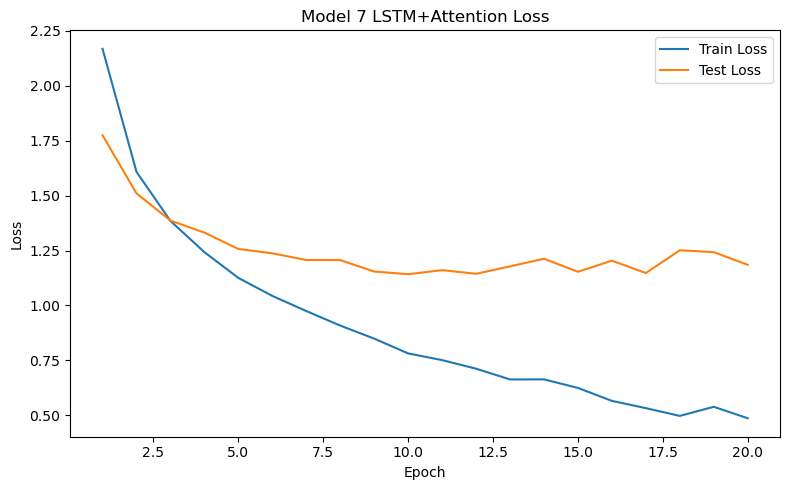

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 9 LSTM+Attention Loss")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model9_lstm_attention_loss.png", dpi=200)
plt.show()

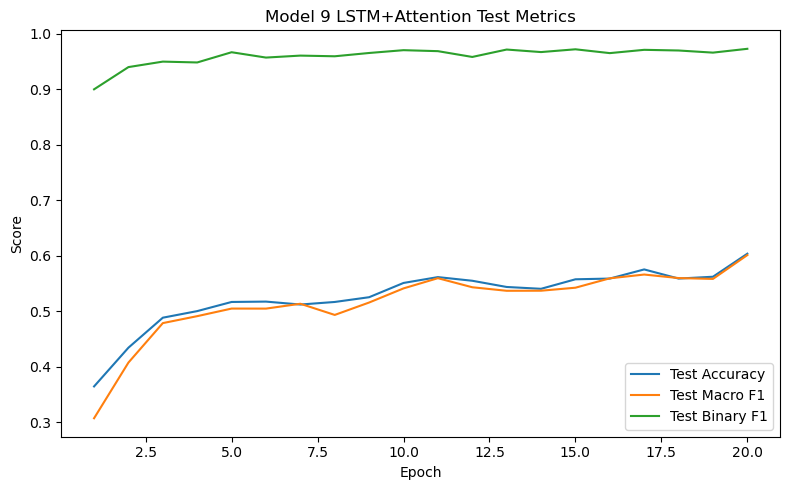

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["test_acc"], label="Test Accuracy")
plt.plot(history_df["epoch"], history_df["test_macroF1"], label="Test Macro F1")
plt.plot(history_df["epoch"], history_df["test_binaryF1"], label="Test Binary F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model 9 LSTM+Attention Test Metrics")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model9_lstm_attention_metrics.png", dpi=200)
plt.show()

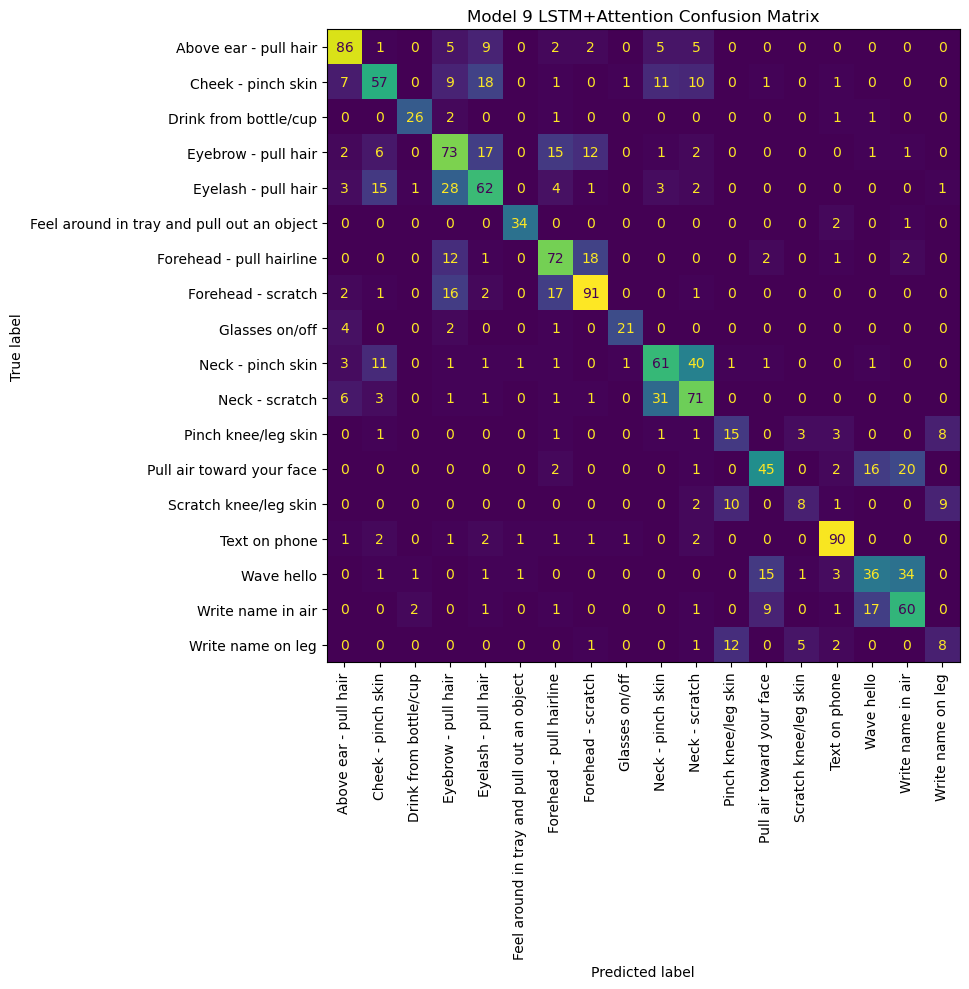

In [34]:
cm = confusion_matrix(best_outputs["y_true_test"], best_outputs["y_pred_test"])

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Model 9 LSTM+Attention Confusion Matrix")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model9_lstm_attention_confusion_matrix.png", dpi=200)
plt.show()